
# 通道自適應自監督學習 / Channel-Adaptive DINO（DINO-BoC）論文講解

> 論文：De Lorenci, Yi, Moutakanni, Bojanowski, Couprie, Caicedo, Pernice,
> ***Scaling Channel-Adaptive Self-Supervised Learning***, TMLR 06/2025
> （官方稱 **DINO-BoC**；程式碼：facebookresearch/dinov2 的 channel-adaptive 分支）

這是我們 **ViT → DINOv2 → 通道自適應** 學習軌跡的第三站：

| Notebook | 學到什麼 |
|---|---|
| `vit_cifar10.ipynb` | ViT 從零實作：patchify、attention、CLS、pos embedding |
| `dinov2_pet.ipynb`  | DINOv2 自監督特徵、forward pass、attention map |
| **本篇** | 當影像**不是 RGB**、而是「通道數與語意都不同」的科學影像時，ViT 要怎麼改？ |

### 🎯 這本要回答的核心問題

自然影像永遠是 3 通道（RGB）。但顯微鏡影像可能是 **2、3、5、7 個通道**，每個通道是一種
**螢光染劑**（細胞核、細胞膜、蛋白質…），而且**不同實驗室的「第 2 通道」語意完全不同**。
要做一個能吃「任意通道組合」的**基礎模型**，有三條路：

1. **Channel-ViT**（聯合編碼 / *early fusion*）：所有通道一開始就丟進同一個 transformer 互相 attention。
2. **DINO-BoC**（獨立編碼 / *late fusion*）：每個通道**各自**過同一個 backbone，最後才把特徵接起來。
3. **DINO-HA**（階層注意力 / *middle*）：用一個**特製的 attention mask**，讓通道內部各自運算、
   只讓一個全域 `[CLS]` token 在語意層級跨通道整合。

### 💡 反直覺的結論（先爆雷）

> 「跨通道推理應該有用」是很自然的直覺。但論文在大規模實驗下發現：
> **獨立編碼（BoC, late fusion）反而大幅打敗聯合編碼（Channel-ViT, early fusion）**，
> 甚至連 RGB 的 ImageNet 都成立。

本 notebook 用**合成玩具資料**把三種架構**真的實作出來、前向跑通**，
讓你親眼看到 patchify、channel embedding、以及最關鍵的 **attention mask** 三者的差別——
不需要下載資料、不需要訓練。


---
## 第 1 章：問題 — 為什麼 RGB 的 ViT 不能直接搬過來？

ViT 的第一層是 `nn.Conv2d(in_channels=3, ...)` 或 `nn.Linear(3*P*P, D)`——**通道數被寫死成 3**。
科學影像打破了三個 RGB 的隱含假設：

| RGB 假設 | 科學影像的現實 |
|---|---|
| 通道數固定 = 3 | 2～8 個不等（不同實驗protocol） |
| 通道語意固定（R/G/B） | 「通道 2」在 A 資料集是細胞核、在 B 是粒線體 |
| 通道間有強相關 | 不同染劑照不同胞器，**可能幾乎無關** |

論文 Fig 2 就是在說這件事：把 HPA、WTC、Cell Painting… 這些資料集疊在一起，
每個資料集的通道數與語意都不一樣。我們先用程式把這個「通道異質性」畫出來。

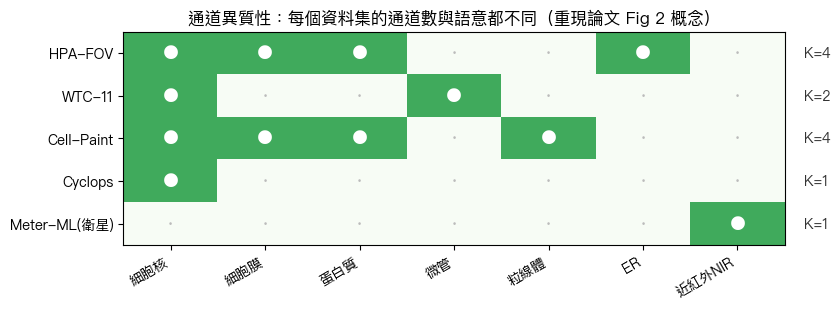

每列通道數 K = [4, 2, 4, 1, 1] → 模型必須吃「可變的 K」


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 自動偵測系統可用的中文字型（跨平台，且不會洗 findfont 警告）
from matplotlib import font_manager as _fm
_cjk = [f for f in ['Microsoft JhengHei', 'PingFang HK', 'PingFang TC', 'Heiti TC',
                    'Arial Unicode MS', 'Noto Sans CJK TC', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei']
        if f in {x.name for x in _fm.fontManager.ttflist}] + ['DejaVu Sans']
plt.rcParams['font.sans-serif'] = _cjk
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 模擬論文 Fig 2：不同資料集 (row) 有不同的通道組合 (col)。X = 該資料集沒有這個通道。
datasets = ["HPA-FOV",  "WTC-11",   "Cell-Paint", "Cyclops", "Meter-ML(衛星)"]
channels  = ["細胞核", "細胞膜", "蛋白質", "微管", "粒線體", "ER", "近紅外NIR"]
# 1 = 有這個通道
present = np.array([
    [1,1,1,0,0,1,0],   # HPA-FOV: 4ch
    [1,0,0,1,0,0,0],   # WTC: 2ch
    [1,1,1,0,1,0,0],   # Cell Painting: 4ch
    [1,0,0,0,0,0,0],   # Cyclops: 1-2ch
    [0,0,0,0,0,0,1],   # 衛星：完全不同 modality
])
fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.imshow(present, cmap="Greens", vmin=0, vmax=1.6, aspect="auto")
for i in range(len(datasets)):
    for j in range(len(channels)):
        ax.text(j, i, "●" if present[i, j] else "·",
                ha="center", va="center",
                color="white" if present[i, j] else "#bbb", fontsize=13, fontweight="bold")
ax.set_xticks(range(len(channels))); ax.set_xticklabels(channels, rotation=30, ha="right")
ax.set_yticks(range(len(datasets))); ax.set_yticklabels(datasets)
ax.set_title("通道異質性：每個資料集的通道數與語意都不同（重現論文 Fig 2 概念）")
n_ch = present.sum(1)
for i, n in enumerate(n_ch):
    ax.text(len(channels) - 0.3, i, f"K={n}", va="center", fontsize=10, color="#333")
plt.tight_layout(); plt.show()
print("每列通道數 K =", n_ch.tolist(), "→ 模型必須吃「可變的 K」")


**重點**：一個寫死 `K=3` 的標準 ViT，連把這幾個資料集**放進同一個模型**都做不到。
所謂 **channel-adaptive（通道自適應）** 模型，就是要能吃「可變數量、可變語意」的通道。


---
## 第 2 章：三種策略總覽（重現論文 Fig 3）

要吃可變通道，關鍵在於**「通道資訊在哪一層融合」**。這就是 *fusion* 的早晚：

- **Early fusion（早融合）**= Channel-ViT：第 0 層所有通道 token 就互相 attention。
- **Late fusion（晚融合）**= DINO-BoC：每通道獨立到底，最後一層才把特徵接起來。
- **Middle（折衷）**= DINO-HA：通道內獨立、只有一個全域 token 在最後做語意整合。

下面這張資料流圖把三者並排（對應論文 Fig 3 的 B/C）。

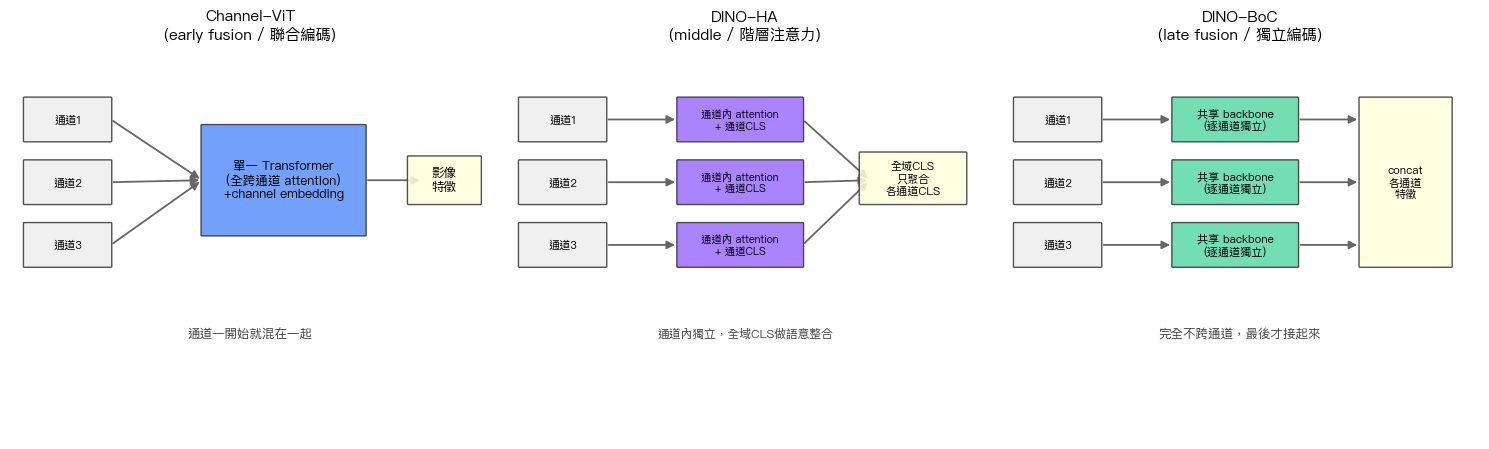

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
titles = ["Channel-ViT\n(early fusion / 聯合編碼)",
          "DINO-HA\n(middle / 階層注意力)",
          "DINO-BoC\n(late fusion / 獨立編碼)"]
colors = ["#5B8FF9", "#9B6DFF", "#5AD8A6"]

def box(ax, x, y, w, h, txt, c, fs=9):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02",
                                fc=c, ec="#333", alpha=0.85))
    ax.text(x + w/2, y + h/2, txt, ha="center", va="center", fontsize=fs)

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>",
                                 mutation_scale=12, color="#666", lw=1.3))

for ax, title, c in zip(axes, titles, colors):
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold")
    for i, yy in enumerate([7.6, 6.0, 4.4]):           # 3 channels
        box(ax, 0.3, yy, 1.8, 1.1, f"通道{i+1}", "#eee", 8)

# Channel-ViT: all channels -> one shared transformer -> CLS
ax = axes[0]
for yy in [7.6, 6.0, 4.4]: arrow(ax, 2.1, yy+0.55, 4.0, 6.6)
box(ax, 4.0, 5.2, 3.4, 2.8, "單一 Transformer\n(全跨通道 attention)\n+channel embedding", colors[0], 9)
arrow(ax, 7.4, 6.6, 8.6, 6.6); box(ax, 8.3, 6.0, 1.5, 1.2, "影像\n特徵", "#ffd")
ax.text(5, 2.6, "通道一開始就混在一起", ha="center", fontsize=9, color="#444")

# DINO-HA: channels independent inside, global CLS aggregates
ax = axes[1]
for yy in [7.6, 6.0, 4.4]:
    arrow(ax, 2.1, yy+0.55, 3.6, yy+0.55)
    box(ax, 3.6, yy, 2.6, 1.1, "通道內 attention\n+ 通道CLS", colors[1], 7.5)
    arrow(ax, 6.2, yy+0.55, 7.6, 6.6)
box(ax, 7.4, 6.0, 2.2, 1.3, "全域CLS\n只聚合\n各通道CLS", "#ffd", 8)
ax.text(5, 2.6, "通道內獨立，全域CLS做語意整合", ha="center", fontsize=8.5, color="#444")

# DINO-BoC: each channel independent through SAME backbone, concat at end
ax = axes[2]
for yy in [7.6, 6.0, 4.4]:
    arrow(ax, 2.1, yy+0.55, 3.6, yy+0.55)
    box(ax, 3.6, yy, 2.6, 1.1, "共享 backbone\n(逐通道獨立)", colors[2], 8)
    arrow(ax, 6.2, yy+0.55, 7.5, yy+0.55)
box(ax, 7.5, 4.4, 1.9, 4.3, "concat\n各通道\n特徵", "#ffd", 8)
ax.text(5, 2.6, "完全不跨通道，最後才接起來", ha="center", fontsize=9, color="#444")

plt.tight_layout(); plt.show()


| | Channel-ViT | DINO-HA | DINO-BoC |
|---|---|---|---|
| 跨通道 attention | **全部**（early） | 只有全域 CLS（middle） | **無**（late） |
| 有 channel embedding? | ✅ 需要（學每個通道身份） | ❌ | ❌ |
| 能吃任意通道數 K? | ❌ 受限於 K_max | ✅ | ✅ |
| 換到沒見過的通道組合 | 容易壞 | 尚可 | **最穩** |
| 論文中大規模表現 | 較差 | 中間 | **最佳** |

接下來我們把這三欄**真的實作出來**。先做共同的資料與 patchify。


---
## 第 3 章：合成多通道「細胞」資料

我們不下載真實顯微影像（檔案大、需網路），而是**程式生成**玩具資料：
每個「細胞影像」有 K 個通道，每個通道是一種**空間結構原型（archetype）**——
細胞核（實心團）、細胞膜（環）、點狀蛋白（puncta）、纖維、瀰漫——
模擬「不同染劑照不同胞器」的特性。這樣完全可重現，又保留了論文要處理的**通道異質**本質。

In [3]:
import numpy as np, torch
torch.manual_seed(0); np.random.seed(0)

IMG, PATCH = 32, 8
G = IMG // PATCH; N = G * G; S2 = PATCH * PATCH   # grid=4, N=16 patches/channel
ARCHETYPES = ["nucleus", "membrane", "puncta", "fiber", "diffuse"]

def make_channel(kind, cx, cy, rng):
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    d = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    if kind == "nucleus":   img = np.exp(-(d**2) / (2 * 6.0**2))               # 實心團
    elif kind == "membrane":img = np.exp(-((d - 9.0)**2) / (2 * 2.0**2))       # 環
    elif kind == "puncta":                                                     # 散點
        img = np.zeros((IMG, IMG))
        for _ in range(12):
            px, py = rng.integers(0, IMG, 2)
            img += np.exp(-(((xx-px)**2 + (yy-py)**2)) / (2 * 1.2**2))
    elif kind == "fiber":   img = (0.5+0.5*np.sin((xx+yy)/2.5+cx))*np.exp(-(d**2)/(2*12.**2))
    else:                   img = (xx + yy) / (2 * IMG)                        # 瀰漫
    return (img / (img.max() + 1e-8)).astype(np.float32)

def make_sample(kinds, seed):
    rng = np.random.default_rng(seed)
    cx, cy = rng.integers(10, 22, 2)                       # 同一細胞中心，各通道共享
    return torch.from_numpy(np.stack([make_channel(k, cx, cy, rng) for k in kinds], 0))

x3 = make_sample(["nucleus", "membrane", "puncta"], seed=7)   # 3 通道樣本
print("一個 3 通道樣本 shape =", tuple(x3.shape), "  (K, H, W)")

一個 3 通道樣本 shape = (3, 32, 32)   (K, H, W)


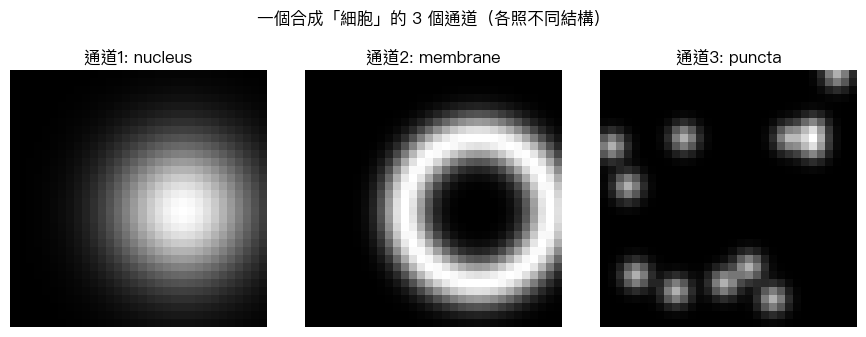

In [4]:
# 視覺化一個樣本的各通道
kinds = ["nucleus", "membrane", "puncta"]
fig, axs = plt.subplots(1, len(kinds), figsize=(9, 3.2))
for j, (ax, k) in enumerate(zip(axs, kinds)):
    ax.imshow(x3[j], cmap="gray"); ax.set_title(f"通道{j+1}: {k}"); ax.axis("off")
fig.suptitle("一個合成「細胞」的 3 個通道（各照不同結構）", y=1.04)
plt.tight_layout(); plt.show()


---
## 第 4 章：共同基礎 — 多通道 patchify

回顧 `vit_cifar10`：ViT 把影像切成 patch、攤平成序列。在通道自適應的世界裡，
論文 §3.1 的關鍵改動是：**把每個通道「各自」切成單通道 patch**，
得到形狀 `(K, N, S²)` —— 每個通道有 N 個 patch，每個 patch 是 S×S 的純量區塊。

$$x = [\,x_{1,1}\;\cdots\;x_{1,N}\;\cdots\;x_{K,1}\;\cdots\;x_{K,N}\,],\quad x_{k,i}\in\mathbb{R}^{S^2}$$

其中 $k$ 是**第幾個通道**、$i$ 是**第幾個 patch 位置**。這個 `(K, N, ...)` 的雙索引，
正是三種策略後面「怎麼排 token、怎麼 mask」的分歧點。

In [5]:
def patchify(x, patch=PATCH):
    '''(K,H,W) -> (K, N, patch*patch). 每個通道獨立切成 N 個單通道 patch。'''
    K, H, W = x.shape
    g = H // patch
    p = x.reshape(K, g, patch, g, patch).permute(0, 1, 3, 2, 4).reshape(K, g*g, patch*patch)
    return p

patches = patchify(x3)
print("patchify:", tuple(x3.shape), "->", tuple(patches.shape), "  (K, N, S^2)")
print(f"  K={patches.shape[0]} 通道, 每通道 N={patches.shape[1]} 個 patch, 每 patch {patches.shape[2]} 維")

patchify: (3, 32, 32) -> (3, 16, 64)   (K, N, S^2)
  K=3 通道, 每通道 N=16 個 patch, 每 patch 64 維


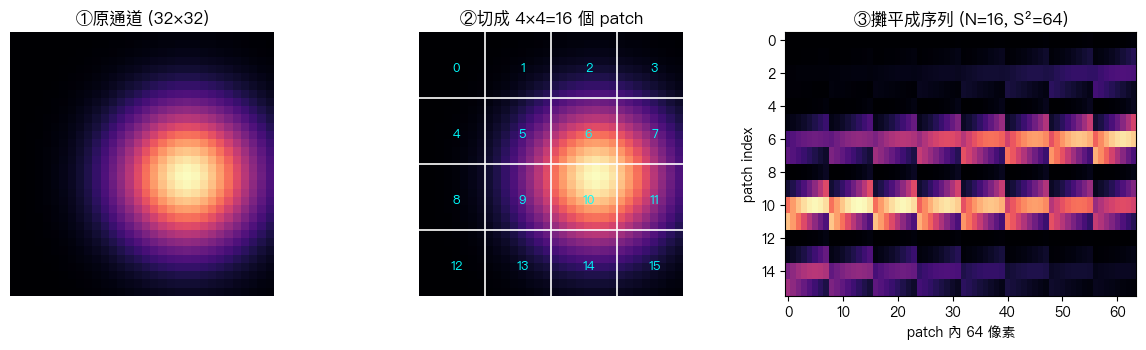

每個通道都這樣處理 → 得到 (K, N, S²)。三種策略的差別，就從「這些 token 怎麼排、能 attend 誰」開始。


In [6]:
# 圖解：影像 -> patch 網格 -> 序列（單一通道示意）
fig, axs = plt.subplots(1, 3, figsize=(12, 3.6))
axs[0].imshow(x3[0], cmap="magma"); axs[0].set_title("①原通道 (32×32)"); axs[0].axis("off")
ax = axs[1]; ax.imshow(x3[0], cmap="magma")
for i in range(1, G):
    ax.axhline(i*PATCH-0.5, color="w", lw=1.2); ax.axvline(i*PATCH-0.5, color="w", lw=1.2)
for idx in range(N):
    r, c = divmod(idx, G)
    ax.text(c*PATCH+PATCH/2, r*PATCH+PATCH/2, str(idx), ha="center", va="center",
            color="cyan", fontsize=9, fontweight="bold")
ax.set_title(f"②切成 {G}×{G}={N} 個 patch"); ax.axis("off")
ax = axs[2]; ax.imshow(patches[0], cmap="magma", aspect="auto")
ax.set_title(f"③攤平成序列 (N={N}, S²={S2})"); ax.set_xlabel("patch 內 64 像素"); ax.set_ylabel("patch index")
plt.tight_layout(); plt.show()
print("每個通道都這樣處理 → 得到 (K, N, S²)。三種策略的差別，就從「這些 token 怎麼排、能 attend 誰」開始。")


### 共用積木：帶 mask 的 Multi-Head Self-Attention

三種策略共用同一個 attention 實作，差別只在**傳不傳 `attn_mask`**（以及 token 怎麼排）。
`attn_mask` 是加性遮罩：`0` = 允許 attend，`-inf` = 禁止（softmax 後變 0）。
這也是我們等下「看出」三種策略差異的核心鈕。

In [7]:
import math, torch.nn as nn, torch.nn.functional as F
D, HEADS = 48, 4   # 刻意做小，方便看 shape

class MHSA(nn.Module):
    def __init__(self, dim=D, heads=HEADS):
        super().__init__()
        self.h, self.dh = heads, dim // heads
        self.qkv = nn.Linear(dim, dim*3); self.proj = nn.Linear(dim, dim)
    def forward(self, x, attn_mask=None, return_attn=False):
        B, T, Dd = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)   # (B,h,T,T)
        if attn_mask is not None:
            att = att + attn_mask              # 0 保留 / -inf 阻擋
        att = att.softmax(-1)
        out = self.proj((att @ v).transpose(1, 2).reshape(B, T, Dd))
        return (out, att) if return_attn else out

print("MHSA ready（dim=%d, heads=%d）" % (D, HEADS))

MHSA ready（dim=48, heads=4）



---
## 第 5 章：策略 A — Channel-ViT（聯合編碼 / early fusion）

論文 §3.1。把所有通道的 patch token **攤平成一條長序列**，丟進**同一個 transformer**，
讓它們從第 0 層就互相 attention。為了讓模型知道「這個 token 來自哪個通道」，
加入**可學習的 channel embedding** $c_k$（類比 pos embedding，但是針對通道）：

$$[\,x_{\text{CLS}}\;\; h_{1,1}+p_1+c_1\;\cdots\; h_{K,N}+p_N+c_K\,]$$

- $p_i$：位置嵌入（第幾個 patch）
- $c_k$：**通道嵌入**（第幾個通道）— 這是 Channel-ViT 的核心，也是它的**罩門**：
  通道嵌入只學到 $K_{\max}$ 個，**通道數超過 $K_{\max}$ 就沒有對應的 $c_k$ 可用**。

In [8]:
class ChannelViT(nn.Module):
    '''聯合編碼：patch + pos + 可學習 channel embedding，全跨通道 attention。'''
    def __init__(self, k_max=4, dim=D):
        super().__init__()
        self.k_max = k_max
        self.patch_embed = nn.Linear(S2, dim)
        self.cls  = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos  = nn.Parameter(torch.randn(1, N, dim) * 0.02)        # 每個位置
        self.chan = nn.Parameter(torch.randn(1, k_max, dim) * 0.02)    # 每個通道（最多 K_max）
        self.attn = MHSA(dim)
    def build_tokens(self, x):
        K = x.shape[0]
        assert K <= self.k_max, f"Channel-ViT 訓練時 K_max={self.k_max}, 但拿到 K={K}（沒有對應的通道嵌入！）"
        h = self.patch_embed(patchify(x)) + self.pos        # (K,N,D) + pos
        h = h + self.chan[0, :K].unsqueeze(1)               # + channel embedding（逐通道）
        seq = h.reshape(1, K*N, -1)                         # 攤平所有通道 -> (1, K*N, D)
        return torch.cat([self.cls, seq], 1)                # 前置 CLS
    def forward(self, x, return_attn=False):
        return self.attn(self.build_tokens(x), return_attn=return_attn)

cvit = ChannelViT(k_max=4)
seq = cvit.build_tokens(x3)
out, att = cvit(x3, return_attn=True)
print("Channel-ViT token 序列:", tuple(seq.shape), " = [CLS] + K*N =", 1, "+", x3.shape[0]*N)
print("輸出:", tuple(out.shape), "| attention:", tuple(att.shape), " (B, heads, T, T)")

Channel-ViT token 序列: (1, 49, 48)  = [CLS] + K*N = 1 + 48
輸出: (1, 49, 48) | attention: (1, 4, 49, 49)  (B, heads, T, T)


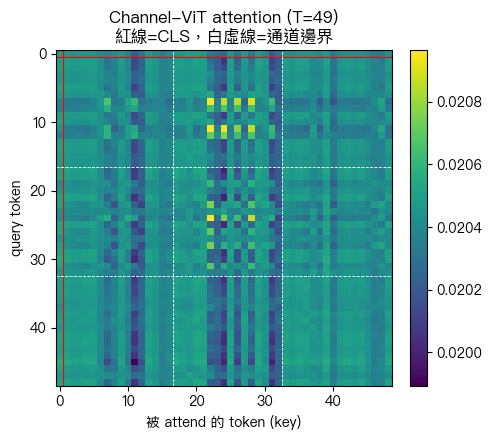

→ 矩陣是「滿的」：通道 1 的 patch 可以直接 attend 通道 3 的 patch。這就是 early fusion。


In [9]:
# 看 attention 矩陣：每個 token 都能 attend 每個 token（full，沒有任何遮擋）
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(att[0].mean(0).detach(), cmap="viridis")
T = seq.shape[1]
ax.axhline(0.5, color="r", lw=0.8); ax.axvline(0.5, color="r", lw=0.8)
for b in range(1, x3.shape[0]):
    ax.axhline(0.5 + b*N, color="w", lw=0.6, ls="--"); ax.axvline(0.5 + b*N, color="w", lw=0.6, ls="--")
ax.set_title("Channel-ViT attention (T=%d)\n紅線=CLS，白虛線=通道邊界" % T)
ax.set_xlabel("被 attend 的 token (key)"); ax.set_ylabel("query token")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()
print("→ 矩陣是「滿的」：通道 1 的 patch 可以直接 attend 通道 3 的 patch。這就是 early fusion。")


**Channel-ViT 的罩門（之後第 10 章會放大看）**：通道嵌入 `self.chan` 只有 `k_max` 個。
拿到比 `k_max` 更多通道的影像時，**沒有對應的 $c_k$**，模型結構上就跑不了。
這正是它「難以泛化到沒見過的通道組合」的根源。

In [10]:
# 通道數 > K_max：結構性失效
try:
    x5 = make_sample(ARCHETYPES, seed=1)        # 5 通道
    cvit(x5)
except AssertionError as e:
    print("K>K_max 時 Channel-ViT 直接報錯：\n  ", e)

K>K_max 時 Channel-ViT 直接報錯：
   Channel-ViT 訓練時 K_max=4, 但拿到 K=5（沒有對應的通道嵌入！）



---
## 第 6 章：策略 B — DINO-BoC（獨立編碼 / late fusion）

論文 §3.2。「Bag of Channels」的想法極簡：**把每個通道當成一張獨立的灰階圖**，
各自過**同一個共享 backbone**，得到各通道的 `[CLS]` 特徵，最後**concat** 起來：

- 訓練時：每次隨機抽**一個**單通道來做 DINOv2 自監督（所以 backbone 是「通道無關」的）。
- 推論時：把影像每個通道分別編碼，特徵接起來 → 得到整張影像表示。

注意：**完全沒有 channel embedding，也沒有跨通道 attention**。
正因如此，它對「通道數 K」毫無限制——這是 late fusion 的最大紅利。

In [11]:
class BoCBackbone(nn.Module):
    '''共享的單通道 ViT。沒有 channel embedding → 通道無關（channel-agnostic）。'''
    def __init__(self, dim=D):
        super().__init__()
        self.patch_embed = nn.Linear(S2, dim)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.randn(1, N, dim) * 0.02)
        self.attn = MHSA(dim)
    def encode_one(self, ch):                       # ch: (H,W) 單通道 -> CLS 特徵 (D,)
        h = self.patch_embed(patchify(ch.unsqueeze(0))) + self.pos    # (1,N,D)
        seq = torch.cat([self.cls, h], 1)                             # (1,1+N,D)
        return self.attn(seq)[0, 0]                                   # CLS token

def boc_features(backbone, x):                      # late fusion = concat
    feats = [backbone.encode_one(x[k]) for k in range(x.shape[0])]
    return torch.cat(feats, 0)                      # (K*D,)

boc = BoCBackbone()
f3 = boc_features(boc, x3)                           # 3 通道
f5 = boc_features(boc, make_sample(ARCHETYPES, seed=1))   # 5 通道：同一個 backbone，毫無問題！
print("BoC 特徵  K=3 ->", tuple(f3.shape), "  (3 個通道各 D=%d，concat)" % D)
print("BoC 特徵  K=5 ->", tuple(f5.shape), "  ← 同一個模型直接吃 5 通道，不需要重訓！")

BoC 特徵  K=3 -> (144,)   (3 個通道各 D=48，concat)
BoC 特徵  K=5 -> (240,)   ← 同一個模型直接吃 5 通道，不需要重訓！


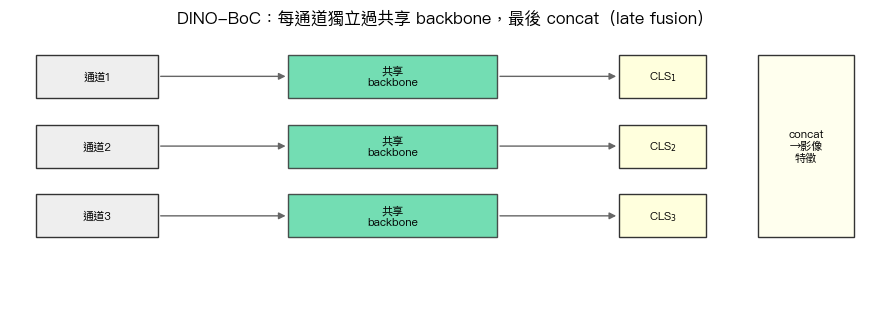

In [12]:
# 圖解：每通道獨立 -> CLS -> concat
K = x3.shape[0]
fig, ax = plt.subplots(figsize=(9, 3.2)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 10)
for i in range(K):
    y = 7.5 - i*2.6
    ax.add_patch(plt.Rectangle((0.3, y), 1.4, 1.6, fc="#eee", ec="#333"))
    ax.text(1.0, y+0.8, f"通道{i+1}", ha="center", va="center", fontsize=8)
    ax.annotate("", (3.2, y+0.8), (1.7, y+0.8), arrowprops=dict(arrowstyle="-|>", color="#666"))
    ax.add_patch(plt.Rectangle((3.2, y), 2.4, 1.6, fc="#5AD8A6", ec="#333", alpha=0.85))
    ax.text(4.4, y+0.8, "共享\nbackbone", ha="center", va="center", fontsize=8)
    ax.annotate("", (7.0, y+0.8), (5.6, y+0.8), arrowprops=dict(arrowstyle="-|>", color="#666"))
    ax.add_patch(plt.Rectangle((7.0, y), 1.0, 1.6, fc="#ffd", ec="#333"))
    ax.text(7.5, y+0.8, f"CLS$_{i+1}$", ha="center", va="center", fontsize=8)
ax.add_patch(plt.Rectangle((8.6, 2.3), 1.1, 6.8, fc="#ffe", ec="#333"))
ax.text(9.15, 5.7, "concat\n→影像\n特徵", ha="center", va="center", fontsize=8)
ax.set_title("DINO-BoC：每通道獨立過共享 backbone，最後 concat（late fusion）")
plt.tight_layout(); plt.show()

### 把 shape 一路追下去（5 通道實例）/ Shape trace, K=5

把上面的方塊圖換成**真實張量的 shape**，逐步看一張 5 通道影像怎麼變成一條影像特徵向量。重點只有一句：**每個通道獨立跑、最後只留 CLS、再 concat**。

> ⚠️ **兩個數字別搞混**：
> - **`S² = 64`** 是「一個 patch 攤平後的**原始像素數**」（$8\times8$），是進 ViT *之前*的輸入維度。
> - **`hidden_dim D = 48`** 是「token 在 ViT *裡面*流動的維度」，由 `Linear(64→48)` 投影而來，是一個**自由設計的超參數**。
>
> 我們**故意把 `D` 設成 48 而不是 64**，就是為了讓你看清楚這兩個是**不同的東西**——只要你選的 hidden_dim 剛好是 64，它們才會「數值上」相等而讓人誤會。進到 transformer 之後，每個 token（含 CLS）一路都是 **`D` 維**，所以最後 concat 出來的影像特徵是 $K \times D = 5 \times 48 = 240$ 維。

輸入影像           : (5, 32, 32)   (K=5, H=32, W=32)
  取 1 個通道      : (32, 32)        <- 拆成 K 張單通道影像，各自獨立
  patchify         : (1, 16, 64)     (N=16 個 patch，每 patch S2=64 像素)
  線性投影 64->48   : (1, 16, 48)     <- 像素數 64 投影到 hidden_dim 48
  前面接上 CLS     : (1, 17, 48)     (1 CLS + 16 patch = 17 token)
  過 ViT backbone  : (1, 17, 48)     (token 數與維度都不變)
  只取出 CLS       : (48,)          <- 每通道濃縮成 1 個 D 維向量
concat 5 個 CLS     : (240,)         = K x D = 5 x 48 = 240（影像特徵）


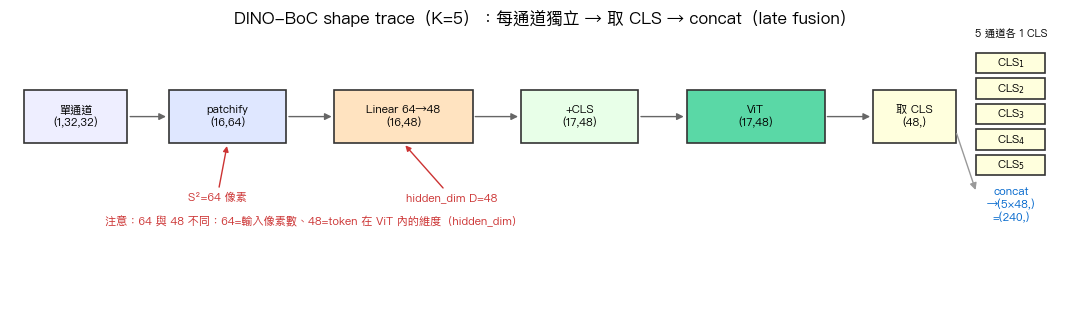

In [13]:
# Shape trace：一張 5 通道影像 -> 5 個 CLS -> concat（用真實張量印出每一步 shape）
# 刻意讓 S2=64（patch 像素）與 D=48（hidden_dim）不同，避免兩個數字被誤會成同一個
K_demo = 5
xK = make_sample(ARCHETYPES, seed=1)                  # (5,H,W) 真的 5 通道樣本
print(f"輸入影像           : {tuple(xK.shape)}   (K={K_demo}, H={IMG}, W={IMG})")
one = xK[0]
print(f"  取 1 個通道      : {tuple(one.shape)}        <- 拆成 K 張單通道影像，各自獨立")
pats = patchify(one.unsqueeze(0))                     # (1,N,S2)
print(f"  patchify         : {tuple(pats.shape)}     (N={N} 個 patch，每 patch S2={S2} 像素)")
emb = boc.patch_embed(pats)                           # (1,N,D)
print(f"  線性投影 {S2}->{D}   : {tuple(emb.shape)}     <- 像素數 {S2} 投影到 hidden_dim {D}")
seq = torch.cat([boc.cls, emb + boc.pos], 1)          # (1,1+N,D)
print(f"  前面接上 CLS     : {tuple(seq.shape)}     (1 CLS + {N} patch = {1+N} token)")
out = boc.attn(seq)                                   # (1,1+N,D)
print(f"  過 ViT backbone  : {tuple(out.shape)}     (token 數與維度都不變)")
cls = out[0, 0]                                       # (D,)
print(f"  只取出 CLS       : {tuple(cls.shape)}          <- 每通道濃縮成 1 個 D 維向量")
feat = boc_features(boc, xK)                          # (K*D,)
print(f"concat {K_demo} 個 CLS     : {tuple(feat.shape)}         = K x D = {K_demo} x {D} = {K_demo*D}（影像特徵）")

# ---- 流程圖 ----
fig, ax = plt.subplots(figsize=(11, 3.4)); ax.axis("off"); ax.set_xlim(0, 15.5); ax.set_ylim(0, 7)
def _box(x, y, w, h, t, fc):
    ax.add_patch(plt.Rectangle((x, y), w, h, fc=fc, ec="#333", lw=1.2))
    ax.text(x+w/2, y+h/2, t, ha="center", va="center", fontsize=8)
def _arr(x0, x1, y): ax.annotate("", (x1, y), (x0, y), arrowprops=dict(arrowstyle="-|>", color="#666"))
yb = 4.3
_box(0.2, yb, 1.5, 1.3, f"單通道\n(1,{IMG},{IMG})", "#eef"); _arr(1.7, 2.3, yb+0.65)
_box(2.3, yb, 1.7, 1.3, f"patchify\n({N},{S2})", "#dfe7ff"); _arr(4.0, 4.7, yb+0.65)
_box(4.7, yb, 2.0, 1.3, f"Linear {S2}→{D}\n({N},{D})", "#ffe3c0"); _arr(6.7, 7.4, yb+0.65)
_box(7.4, yb, 1.7, 1.3, f"+CLS\n({1+N},{D})", "#e8ffe8"); _arr(9.1, 9.8, yb+0.65)
_box(9.8, yb, 2.0, 1.3, f"ViT\n({1+N},{D})", "#5AD8A6"); _arr(11.8, 12.5, yb+0.65)
_box(12.5, yb, 1.2, 1.3, f"取 CLS\n({D},)", "#ffd")
ax.annotate(f"S²={S2} 像素", (3.15, yb), (3.0, yb-1.4), fontsize=8, color="#c33", ha="center",
            arrowprops=dict(arrowstyle="-|>", color="#c33"))
ax.annotate(f"hidden_dim D={D}", (5.7, yb), (6.4, yb-1.4), fontsize=8, color="#c33", ha="center",
            arrowprops=dict(arrowstyle="-|>", color="#c33"))
ax.text(4.4, yb-2.0, f"注意：{S2} 與 {D} 不同：{S2}=輸入像素數、{D}=token 在 ViT 內的維度（hidden_dim）",
        ha="center", fontsize=8, color="#c33")
for i in range(5):
    _box(14.0, 6.0 - i*0.62, 1.0, 0.5, f"CLS$_{i+1}$", "#ffd")
ax.text(14.5, 6.9, "5 通道各 1 CLS", ha="center", fontsize=7.5)
ax.annotate("", (14.0, 3.1), (13.7, yb+0.3), arrowprops=dict(arrowstyle="-|>", color="#999"))
ax.text(14.5, 2.4, f"concat\n→({K_demo}×{D},)\n=({K_demo*D},)", ha="center", fontsize=8, color="#06c")
ax.set_title(f"DINO-BoC shape trace（K={K_demo}）：每通道獨立 → 取 CLS → concat（late fusion）")
plt.tight_layout(); plt.show()

### 🔬 對照官方原始碼：BoC 其實「沒有新模型」

打開你 fork 的 `facebookresearch/dinov2`（channel-adaptive 分支）會發現一件很反直覺的事：
**Bag-of-Channels 根本沒有自訂架構**——它就是一個 `in_chans=1` 的*標準* DINOv2 ViT，
加上**一行 reshape**把通道塞進 batch 維度：

```python
# dinov2/models/vision_transformer.py:310
if self.bag_of_channels:
    B, C, H, W = x.shape
    x = x.reshape(B * C, 1, H, W)   # 把 C 個通道變成 batch 裡 C 個獨立單通道樣本
```

- **訓練設定** `configs/train/cell_dino/vitl16_boc_hpafov.yaml`：`channel_adaptive: true`、**`in_chans: 1`**。
- **資料層** `SEPARATE_CHANNELS`（`data/datasets/cell_dino/hpafov.py`）：每個通道被當成**獨立樣本**，
  所以預訓練時模型一次只看到一個通道——這正是「通道無關（channel-agnostic）」的來源。
- **「融合」發生在評估端、不在 backbone**：`create_linear_input`（`eval/cell_dino/linear.py:247`）
  把各通道的 class token **concat** 起來——late fusion 說穿了就是一個 `torch.cat`。

我們 §6 的 `encode_one` 逐通道迴圈，跟官方那行 `reshape(B*C,1,H,W)` 是**同一件事**，
只是官方用 batch 維度向量化。下面就驗證兩者**數值完全相等**。

In [14]:
# 官方做法：把通道當成 batch，一次前向跑完所有通道（向量化版，對應 reshape(B*C,1,H,W)）
def boc_features_vectorized(backbone, x):
    C, H, W = x.shape
    h = backbone.patch_embed(patchify(x)) + backbone.pos       # (C,N,D)  ← C 直接當 batch
    seq = torch.cat([backbone.cls.expand(C, 1, -1), h], 1)     # (C,1+N,D)
    cls = backbone.attn(seq)[:, 0]                             # (C,D) 每通道一個 CLS
    return cls.reshape(-1)                                     # concat → (C*D,)

fa = boc_features(boc, x3)              # §6 逐通道迴圈
fb = boc_features_vectorized(boc, x3)  # 官方 reshape 向量化
print("逐通道迴圈 vs 官方 reshape 向量化 → 數值相等:", torch.allclose(fa, fb, atol=1e-6))
print("→ 證實 BoC 不需要任何新模型：標準 in_chans=1 的 ViT + 一行 reshape 就是全部。")
print("  (這也是論文說 BoC『lacking any priors / 極簡』的字面意思)")

逐通道迴圈 vs 官方 reshape 向量化 → 數值相等: True
→ 證實 BoC 不需要任何新模型：標準 in_chans=1 的 ViT + 一行 reshape 就是全部。
  (這也是論文說 BoC『lacking any priors / 極簡』的字面意思)



---
## 第 7 章：策略 C — DINO-HA（階層注意力）★ 重頭戲

論文 §3.3。HA 想在 early 與 late 之間取折衷：**通道內部各自運算，但保留一個全域 token 做跨通道整合。**
作法是**一個特製的 attention mask**。token 序列排成：

$$[\,x_{\text{CLS}}\;\;|\;\;x_{\text{CH}_1}\cdots x_{\text{CH}_K}\;\;|\;\;\text{通道1的 N 個 patch}\;\cdots\;\text{通道K的 N 個 patch}\,]$$

mask 規則（這就是整篇論文最值得「看出來」的物件）：

1. **某通道的 patch** 只能 attend **同通道**的 token（自己的 patch + 自己的通道 CLS）→ 通道間 patch 完全隔離。
2. **通道 CLS** $x_{\text{CH}_k}$ 在自己通道內運算。
3. **全域 CLS** $x_{\text{CLS}}$ 只 attend **所有通道 CLS**——跨通道整合**只發生在這個語意層級**。

我們直接把這個 mask 建出來、畫成 heatmap，再驗證它真的擋住了跨通道 patch attention。

> **📌 誠實說明：官方原始碼只釋出 BoC，沒有 HA。**
> 你 fork 的 repo 在 `docs/README_CHANNEL_ADAPTIVE_DINO.md` 明寫：
> *“This repository includes the Bag of Channel implementation, not the Hierarchical attention approach.”*
> 因此本章的 **DINO-HA 是依論文 §3.3 文字描述忠實重建**的教學版本（attention mask 規則照論文），
> 並非官方釋出程式碼；而 **§6 的 BoC 則與官方實作一致**。這也呼應論文把 HA 定位成
> 「用來*分析* early vs late fusion 的控制實驗」，而非要釋出的產品模型。

In [15]:
def ha_attention_mask(K, n=N):
    '''
    token 排列: [ x_CLS | x_CH_1..x_CH_K | 通道1 patches(N) | ... | 通道K patches(N) ]
    回傳加性 mask (T,T): 0=允許, -inf=阻擋。
    '''
    T = 1 + K + K*n
    allow = torch.zeros(T, T, dtype=torch.bool)
    gcls = 0
    ch_idx    = lambda k: 1 + k
    patch_idx = lambda k: range(1 + K + k*n, 1 + K + (k+1)*n)
    # 全域 CLS <-> 各通道 CLS（唯一的跨通道路徑）
    allow[gcls, gcls] = True
    for k in range(K):
        allow[gcls, ch_idx(k)] = True
        allow[ch_idx(k), gcls] = True
    # 每個通道內部：{通道CLS} ∪ {該通道 patches} 形成一個全連通 clique
    for k in range(K):
        members = [ch_idx(k)] + list(patch_idx(k))
        for a in members:
            for b in members:
                allow[a, b] = True
    mask = torch.zeros(T, T); mask[~allow] = float("-inf")
    return mask

m3 = ha_attention_mask(3)
print("HA mask shape:", tuple(m3.shape), "| 被阻擋比例:", round(float((m3==float('-inf')).float().mean()),3))

HA mask shape: (52, 52) | 被阻擋比例: 0.677


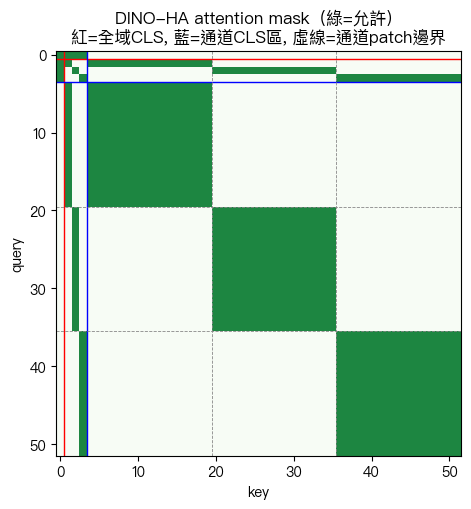

看出三件事：①對角線上每個通道是獨立方塊  ②全域CLS(第0列)只通到通道CLS(藍區)  ③通道間 patch 互不相連


In [16]:
# heatmap：把 HA 的注意力結構「看出來」（重現論文 Fig 4 的 mask 概念）
K = 3; T = 1 + K + K*N
fig, ax = plt.subplots(figsize=(6, 5.2))
ax.imshow((m3 == 0).float(), cmap="Greens", vmin=0, vmax=1.3)
# 邊界線：CLS | 通道CLS | 各通道 patch 區塊
ax.axhline(0.5, color="r", lw=1); ax.axvline(0.5, color="r", lw=1)
ax.axhline(K+0.5, color="b", lw=1); ax.axvline(K+0.5, color="b", lw=1)
for k in range(1, K):
    ax.axhline(K+0.5+k*N, color="#888", lw=0.6, ls="--")
    ax.axvline(K+0.5+k*N, color="#888", lw=0.6, ls="--")
ax.set_title("DINO-HA attention mask（綠=允許）\n紅=全域CLS, 藍=通道CLS區, 虛線=通道patch邊界")
ax.set_xlabel("key"); ax.set_ylabel("query"); plt.tight_layout(); plt.show()
print("看出三件事：①對角線上每個通道是獨立方塊  ②全域CLS(第0列)只通到通道CLS(藍區)  ③通道間 patch 互不相連")

In [17]:
class DinoHA(nn.Module):
    '''通道內 block-diagonal attention + 全域 CLS 聚合各通道 CLS。'''
    def __init__(self, dim=D):
        super().__init__()
        self.patch_embed = nn.Linear(S2, dim)
        self.gcls  = nn.Parameter(torch.zeros(1, 1, dim))   # 全域 CLS
        self.chcls = nn.Parameter(torch.zeros(1, 1, dim))   # 通道 CLS（共享初始化）
        self.pos   = nn.Parameter(torch.randn(1, N, dim) * 0.02)
        self.attn  = MHSA(dim)
    def build_tokens(self, x):
        K = x.shape[0]
        patches = (self.patch_embed(patchify(x)) + self.pos).reshape(1, K*N, -1)
        chcls = self.chcls.expand(1, K, -1)
        return torch.cat([self.gcls, chcls, patches], 1), K
    def forward(self, x, return_attn=False):
        seq, K = self.build_tokens(x)
        mask = ha_attention_mask(K).unsqueeze(0).unsqueeze(0)   # (1,1,T,T)
        return self.attn(seq, attn_mask=mask, return_attn=return_attn)

ha = DinoHA()
out_ha, att_ha = ha(x3, return_attn=True)
print("HA 輸出:", tuple(out_ha.shape), "| attention:", tuple(att_ha.shape))

# 驗證 mask 真的有效：通道0 的 patch 對通道1 的 patch 的注意力應為 0
p0 = list(range(1+3+0*N, 1+3+1*N)); p1 = list(range(1+3+1*N, 1+3+2*N))
leak = att_ha[0, :, p0][:, :, p1].sum().item()
print(f"通道0→通道1 的 patch 注意力總和 = {leak:.6f}  （應為 0 → mask 確實隔離了通道）")

HA 輸出: (1, 52, 48) | attention: (1, 4, 52, 52)
通道0→通道1 的 patch 注意力總和 = 0.000000  （應為 0 → mask 確實隔離了通道）



---
## 第 8 章：三者並排對比 — 一張圖看懂 early / middle / late

把三種策略的 attention **可達結構**並排畫出來。注意三者其實可以統一成「同一個 attention、
不同 mask」的觀點：

- **Channel-ViT**：mask 全開（full）→ early fusion。
- **DINO-HA**：通道內 block + 全域 CLS 橋接 → middle。
- **DINO-BoC**：完全 block-diagonal、各通道獨立序列、無任何跨通道 → late fusion。

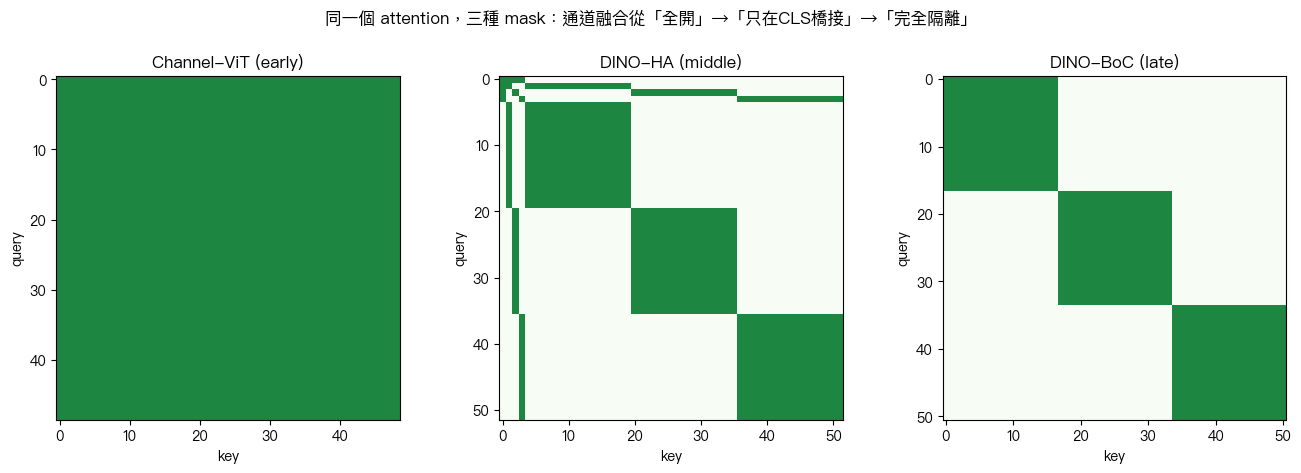

In [18]:
def channelvit_mask(K): return torch.zeros(1 + K*N, 1 + K*N)          # 全開
def boc_mask(K):                                                      # 純 block-diagonal
    T = (1+N)*K; mask = torch.full((T, T), float("-inf"))
    for k in range(K):
        s = k*(1+N); mask[s:s+1+N, s:s+1+N] = 0.0
    return mask

K = 3
masks = [("Channel-ViT (early)", channelvit_mask(K)),
         ("DINO-HA (middle)",    ha_attention_mask(K)),
         ("DINO-BoC (late)",     boc_mask(K))]
fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.4))
for ax, (name, mk) in zip(axs, masks):
    ax.imshow((mk == 0).float(), cmap="Greens", vmin=0, vmax=1.3)
    ax.set_title(name); ax.set_xlabel("key"); ax.set_ylabel("query")
fig.suptitle("同一個 attention，三種 mask：通道融合從「全開」→「只在CLS橋接」→「完全隔離」", y=1.03)
plt.tight_layout(); plt.show()


| 面向 | Channel-ViT | DINO-HA | DINO-BoC |
|---|---|---|---|
| 融合時機 | early（第0層） | middle（CLS層級） | late（最後 concat） |
| 跨通道 patch attention | ✅ 全部 | ❌ | ❌ |
| channel embedding | ✅ 必要 | ❌ | ❌ |
| 通道無關（任意 K）| ❌（≤K_max）| ✅ | ✅ |
| 換未見通道組合 | 脆弱 | 中等 | **最穩** |
| 論文大規模結果 | 較差 | 中間 | **SOTA** |


---
## 第 9 章：論文主結果解讀 — 為什麼 late fusion 反而贏？

論文用 ViT-L 在百萬級顯微影像上做 DINOv2 自監督，跑了一整套 benchmark。下面用論文的
**實際數字**重畫幾張關鍵對比（我們無法重現大規模訓練，但可以解讀趨勢）。

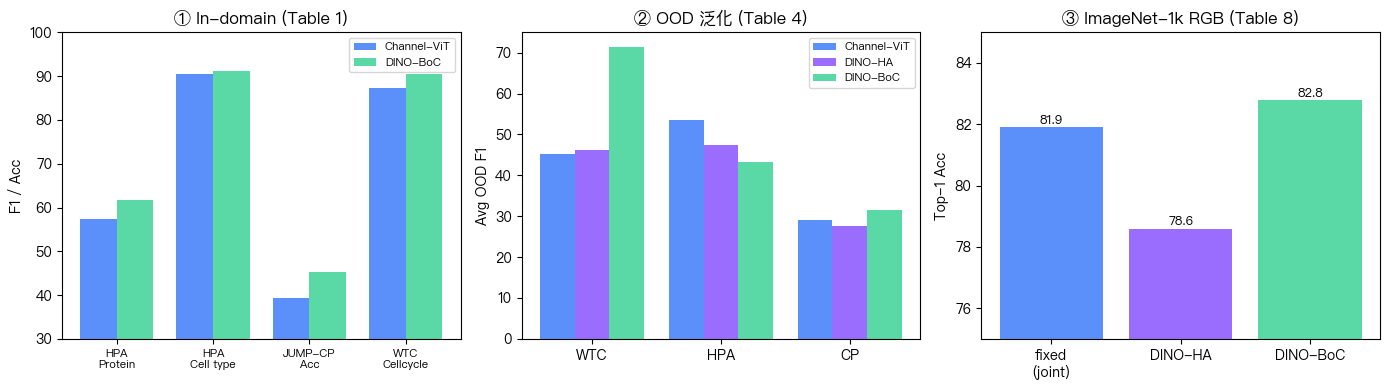

In [19]:
# 論文 Table 1 / Table 4 / Table 8 的代表性數字
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

# (1) ExtendedCHAMMI 上 in-domain (Table 1, DINOv2 ViT-L)
ax = axs[0]
tasks = ["HPA\nProtein", "HPA\nCell type", "JUMP-CP\nAcc", "WTC\nCellcycle"]
cvit_v = [57.4, 90.4, 39.4, 87.2]; boc_v = [61.7, 91.1, 45.2, 90.5]
xp = np.arange(len(tasks)); w = 0.38
ax.bar(xp-w/2, cvit_v, w, label="Channel-ViT", color="#5B8FF9")
ax.bar(xp+w/2, boc_v,  w, label="DINO-BoC",    color="#5AD8A6")
ax.set_xticks(xp); ax.set_xticklabels(tasks, fontsize=8); ax.set_ylim(30, 100)
ax.set_title("① In-domain (Table 1)"); ax.set_ylabel("F1 / Acc"); ax.legend(fontsize=8)

# (2) CHAMMI OOD 平均 (Table 4, 1-NN)
ax = axs[1]
ood = ["WTC", "HPA", "CP"]
cvit_o = [45.3, 53.6, 29.0]; ha_o = [46.3, 47.4, 27.5]; boc_o = [71.4, 43.3, 31.6]
xp = np.arange(len(ood)); w = 0.27
ax.bar(xp-w, cvit_o, w, label="Channel-ViT", color="#5B8FF9")
ax.bar(xp,   ha_o,   w, label="DINO-HA",     color="#9B6DFF")
ax.bar(xp+w, boc_o,  w, label="DINO-BoC",    color="#5AD8A6")
ax.set_xticks(xp); ax.set_xticklabels(ood); ax.set_title("② OOD 泛化 (Table 4)")
ax.set_ylabel("Avg OOD F1"); ax.legend(fontsize=8)

# (3) ImageNet-1k RGB (Table 8) — 連自然影像都成立
ax = axs[2]
models = ["fixed\n(joint)", "DINO-HA", "DINO-BoC"]
acc = [81.9, 78.6, 82.8]
ax.bar(models, acc, color=["#5B8FF9", "#9B6DFF", "#5AD8A6"])
ax.set_ylim(75, 85); ax.set_title("③ ImageNet-1k RGB (Table 8)"); ax.set_ylabel("Top-1 Acc")
for i, a in enumerate(acc): ax.text(i, a+0.1, str(a), ha="center", fontsize=9)
plt.tight_layout(); plt.show()


**怎麼解讀？**

- **① In-domain**：即使在訓練分佈內，BoC 也全面小贏 Channel-ViT。
- **② OOD（換通道組合 / 換資料集）**：差距**爆開**——BoC 在 WTC 上 71.4 vs 45.3。
  這正是 late fusion 的紅利：沒有把通道 *綁死* 在一起，換新的通道組合時不會崩。
- **③ ImageNet RGB**：連通道高度相關的自然影像，獨立編碼 (82.8) 都贏聯合編碼 (81.9)。

**為什麼會這樣？** 論文的解釋是：聯合編碼（early fusion）等於對「通道之間的關係」下了一個
**先驗（prior）**。在自然影像這個先驗大致成立；但科學影像的通道關係**多變且資料相依**，
把容量花在學特定的跨通道關係，反而**犧牲了泛化**。獨立編碼把每個通道的資訊**完整保留**，
跨通道整合留到下游（concat 後接 linear probe）再做，反而更穩、更通用。

> **🧪 這個 fork 真的把論文數字重現出來了**：`README_CHANNEL_ADAPTIVE_DINO.md` 附了重現結果。
> 以 CHAMMI 的 **kNN F1（reproduced / paper）** 為例：HPA-T1 **91.6 / 86.6**、WTC-T1 **80.3 / 79.4**、
> CP-T1 **89.8 / 92.6**；**linear probe** HPA-T2 **87.2 / 84.7**、HPA-T3 **66.2 / 65.0**。
> 個別數字略有上下，但 **BoC 的整體趨勢與 SOTA 地位被獨立重現**——不是只存在於原論文表格裡。


---
## 第 10 章：機制小實驗 — 親眼看出「為何 BoC 更會泛化」

我們不訓練，但可以用合成資料**機械式地**示範論文結論的根源：
**面對「沒見過的通道組合 / 更多通道」時，BoC 結構上毫無障礙，Channel-ViT 直接卡死。**

In [20]:
# 模擬「部署到新資料集」：訓練時見過 K_max=4，部署時來了 K=2,3,4,5,6,7 各種通道數
K_max = 4
print(f"{'通道數K':>6} | {'Channel-ViT(K_max=4)':>22} | {'DINO-BoC':>12}")
print("-"*48)
cvit_test = ChannelViT(k_max=K_max); boc_test = BoCBackbone()
for K in [2, 3, 4, 5, 6, 7]:
    kinds = (ARCHETYPES * 2)[:K]
    x = make_sample(kinds, seed=100+K)
    # Channel-ViT
    try:
        cvit_test(x); cv = "✅ 可前向"
    except AssertionError:
        cv = "❌ 結構失效"
    # BoC
    feat = boc_features(boc_test, x); bo = f"✅ feat {tuple(feat.shape)}"
    print(f"{K:>6} | {cv:>22} | {bo:>12}")
print("\n→ Channel-ViT 一旦 K>K_max 就沒有對應的 channel embedding，無法部署；")
print("  BoC 因為通道無關，2~7 通道照單全收。這就是論文『泛化到未見通道組合』結論的機制根源。")

  通道數K |   Channel-ViT(K_max=4) |     DINO-BoC
------------------------------------------------
     2 |                  ✅ 可前向 | ✅ feat (96,)
     3 |                  ✅ 可前向 | ✅ feat (144,)
     4 |                  ✅ 可前向 | ✅ feat (192,)
     5 |                 ❌ 結構失效 | ✅ feat (240,)
     6 |                 ❌ 結構失效 | ✅ feat (288,)
     7 |                 ❌ 結構失效 | ✅ feat (336,)

→ Channel-ViT 一旦 K>K_max 就沒有對應的 channel embedding，無法部署；
  BoC 因為通道無關，2~7 通道照單全收。這就是論文『泛化到未見通道組合』結論的機制根源。


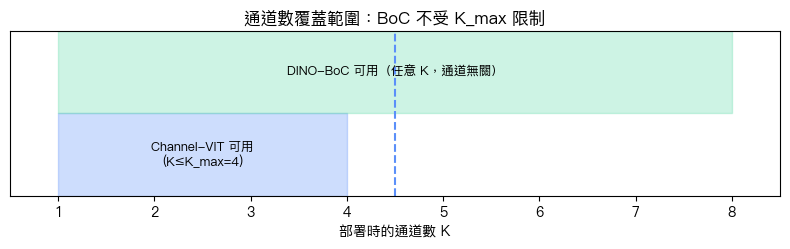

In [21]:
# 視覺化：可用通道數範圍
fig, ax = plt.subplots(figsize=(8, 2.6))
Ks = np.arange(1, 9)
ax.fill_between([1, K_max], 0, 1, color="#5B8FF9", alpha=0.3)
ax.fill_between([1, 8], 1, 2, color="#5AD8A6", alpha=0.3)
ax.axvline(K_max+0.5, color="#5B8FF9", ls="--")
ax.text(K_max/2+0.5, 0.5, f"Channel-ViT 可用\n(K≤K_max={K_max})", ha="center", va="center", fontsize=9)
ax.text(4.5, 1.5, "DINO-BoC 可用（任意 K，通道無關）", ha="center", va="center", fontsize=9)
ax.set_xlim(0.5, 8.5); ax.set_ylim(0, 2); ax.set_yticks([]); ax.set_xticks(Ks)
ax.set_xlabel("部署時的通道數 K"); ax.set_title("通道數覆蓋範圍：BoC 不受 K_max 限制")
plt.tight_layout(); plt.show()

---
## 附錄 A：玩具 ↔ 官方原始碼對照

把本 notebook 的每個玩具元件，對應到你 fork 的 `facebookresearch/dinov2`（channel-adaptive 分支）真實檔案：

| 本 notebook 的玩具 | 官方原始碼位置 |
|---|---|
| `patchify`：(K,H,W) 切 patch | `dinov2/layers/patch_embed.py` → `PatchEmbed`（標準 Conv2d，BoC 設 `in_chans=1`）|
| `BoCBackbone` 逐通道編碼 | `dinov2/models/vision_transformer.py:310` → `x.reshape(B*C, 1, H, W)`（通道塞進 batch）|
| BoC concat 各通道 CLS（late fusion）| `dinov2/eval/cell_dino/linear.py:247` → `create_linear_input`（`torch.cat` class tokens）|
| 「每通道當獨立樣本」 | 資料層 `SEPARATE_CHANNELS`（`dinov2/data/datasets/cell_dino/hpafov.py`）|
| 訓練超參 | `configs/train/cell_dino/vitl16_boc_hpafov.yaml`（`channel_adaptive: true`, `in_chans: 1`, ViT-L/16）|
| `ChannelViT` 的 channel embedding | 論文 §3.1（官方 repo 未釋出此 baseline）|
| `DinoHA` attention mask | 論文 §3.3（官方 repo **未釋出**，本篇為重建）|

**怎麼用這張表自學**：先在 notebook 裡用玩具看懂機制（shape、mask、concat），
再去 fork 對應檔案讀「正式、可訓練、會處理 batch / register token / 多 block」的完整版本——
你會發現核心邏輯其實就是我們跑過的那幾行。


---
## 第 11 章：總結與延伸

### 一句話總結
> 在通道異質的科學影像上，**把每個通道獨立編碼、最後才融合（DINO-BoC / late fusion）**，
> 比讓通道從頭互相 attention（Channel-ViT / early fusion）**更強也更通用**——
> 因為它不對「跨通道關係」下死板的先驗，因此能泛化到任意、未見過的通道組合。

### 三種策略何時用？
| 你的情境 | 建議 |
|---|---|
| 通道數固定、通道間高度相關、要顯式跨通道推理（如蛋白質定位 vs 參考通道）| Channel-ViT 或 **加 linear probe 的 BoC** |
| 通道數多變、要做跨資料集 / 跨實驗的基礎模型 | **DINO-BoC** |
| 想要折衷、保留一點跨通道語意整合 | DINO-HA |

### 本篇學到的三個可遷移機制
1. **多通道 patchify**：`(K,H,W) → (K,N,S²)`，雙索引 (通道, 位置) 是一切的起點。
2. **channel embedding 是雙面刃**：給了通道身份，卻把模型綁死在 `K_max`。
3. **attention mask = 融合策略的旋鈕**：同一個 attention，full / hierarchical / block-diagonal
   三種 mask 就對應 early / middle / late fusion。

### 延伸方向
- 官方程式碼與權重：`facebookresearch/dinov2` 的 `README_CHANNEL_ADAPTIVE_DINO.md`。
- 把第 6 章的 `BoCBackbone` 換成**真正的預訓練 DINOv2**（接上 `dinov2_pet.ipynb` 學到的載入方式），
  對每個通道抽特徵再 concat，就是論文 inference 的真實作法。
- 真實資料可看 **CHAMMI** benchmark（通道自適應的標準評測）。

---
*學習軌跡：`vit_cifar10` →（ViT 基礎）→ `dinov2_pet` →（DINOv2 / SSL）→ **本篇**（通道自適應）。*